<a href="https://colab.research.google.com/github/jeeva477/Deep-Learning/blob/main/Convolutionl_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower-dimensional latent representation and reconstructs them with minimal loss of information.

Purpose

A Convolutional Autoencoder is an unsupervised deep learning model used for.

Image Compression Image Reconstruction Feature Extraction Dimensionality Reduction

The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from this compressed representation.

In [47]:
# kagglehub: Downloads and manages datasets from Kaggle
import kagglehub
# os: Handles file paths and directory operations
import os
# shutil: Used for copying, moving, and deleting files or folders
import shutil
# numpy: Performs numerical computations and array operations
import numpy as np
# matplotlib.pyplot: Displays images, graphs, and training results
import matplotlib.pyplot as plt
# tensorflow: Main deep learning framework used to build and train the Convolutional Autoencoder
import tensorflow as tf
# Conv2D: Extracts image features using convolutional filters
# MaxPooling2D: Reduces image dimensions to create a compressed representation
# UpSampling2D: Increases image dimensions during reconstruction
# Input: Defines the input shape of the neural network
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input
# Model: Combines the encoder and decoder into a complete Convolutional Autoencoder model
from tensorflow.keras.models import Model
# ImageDataGenerator: Loads and preprocesses image datasets efficiently
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [48]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [49]:
#create a smaller dataset(5000 images)
# Specify the path to the original CelebA image folder
source_folder= os.path.join(path, "img_align_celeba", "img_align_celeba")
# Create a new folder to store the selected images
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)# Create the folder if it doesn't already exist
images = sorted(os.listdir(source_folder))[:5000]# Get a sorted list of image filenames and select the first 5000 images
# Copy the selected images from the source folder to the destination folder
for img in images:
  shutil.copy(
      os.path.join(source_folder,img),
      destination_folder
  )

In [50]:
# data preprocessing
# Resize all images to 64×64 for faster training and lower memory usage
image_size = (64, 64)
# Process 32 images at a time for efficient and stable training
batch_size = 32

In [51]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [52]:
#load dataset
train_generator =datagen.flow_from_directory(
    "celeba_small",target_size=image_size,#Uses the input image as the target output
    batch_size=batch_size,class_mode="input",subset="training"
)

Found 4000 images belonging to 1 classes.


In [53]:
validation_generator =datagen.flow_from_directory(
    "celeba_small",target_size=image_size,
    batch_size=batch_size,class_mode="input",subset="validation"
)

Found 1000 images belonging to 1 classes.


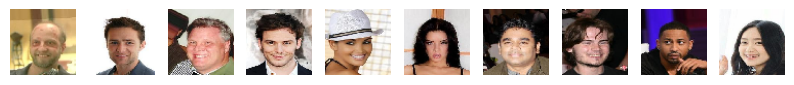

In [54]:
#dispaly samples images
images,_=next(train_generator)
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(1,10,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [55]:
# build convolutional autoencoder
#encoder
input_img=Input(shape=(64,64,3))
x=Conv2D(
    32,(3,3),activation='relu',padding='same'
)(input_img)

x= MaxPooling2D(
    (2,2),padding='same'
)(x)

x=Conv2D(
    64,(3,3),activation='relu',padding='same'
)(x)

encoded = MaxPooling2D(
    (2,2),padding='same'
)(x)

In [56]:
#decoder
x=Conv2D(
    64,(3,3),activation='relu',padding='same'
)(encoded)

x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(
    3,(3,3),activation='sigmoid',padding='same'
  )(x)

In [57]:
#create model
autoencoder = Model(
    input_img, decoded
)

In [58]:
# complie modle
autoencoder.compile(
    optimizer='adam',loss='binary_crossentropy'
)

In [59]:
#Model summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# train model
history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.5245 - val_loss: 0.4978
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.4927 - val_loss: 0.4913
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.4890 - val_loss: 0.4883
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.4863 - val_loss: 0.4863
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4853 - val_loss: 0.4848
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4846 - val_loss: 0.4842
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.4838 - val_loss: 0.4832
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.4831 - val_loss: 0.4828
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.4834 - val_loss: 0.4847
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.4827 - val_loss: 0.4825


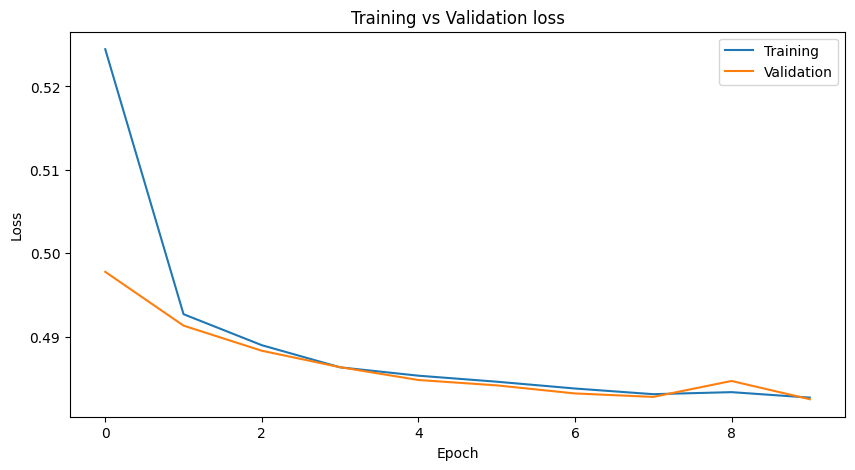

In [61]:
#loss graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation loss")
plt.legend(["Training","Validation"])
plt.show()

In [62]:
#evaluate model
loss=autoencoder.evaluate(validation_generator)
print("validation loss :",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.4825
validation loss : 0.4825054109096527


In [63]:
#reconstruct images
images,_=next(validation_generator)
reconstructed=autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step


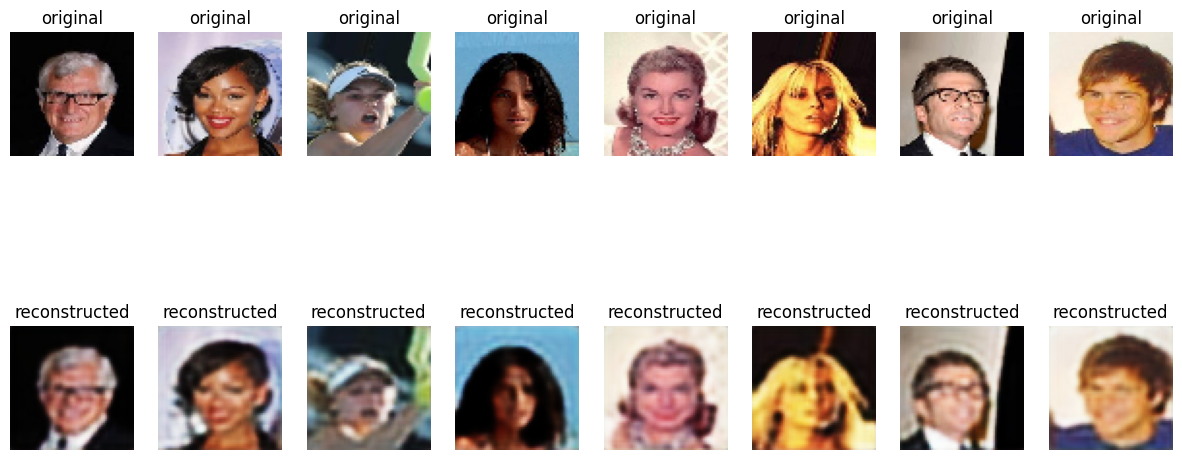

In [74]:
#display results
n=8
plt.figure(figsize=(15,7))

for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.title("original")
    plt.axis("off")
    plt.subplot(2,n,i+n+1)
    plt.imshow(reconstructed[i])
    plt.title("reconstructed")
    plt.axis("off")
plt.show()
